# Curso de Especialización en Python — Desarrollo profundo por módulos

A continuación se desarrollan con **profundidad teórica y práctica** todos los epígrafes, explicados para un estudiante de informática. Cada epígrafe incluye: **conceptos clave**, **explicación razonada**, **ejemplos ejecutables**, **errores frecuentes** y **batería de test**.

---
## Configuración inicial — Instalación de librerías necesarias

Ejecuta la siguiente celda para instalar todas las dependencias del curso.
Asegúrate de haber seleccionado el intérprete Python correcto en el menú **Kernel → Change kernel** (Jupyter) o en la barra superior de VS Code / Kiro.

In [1]:
# Instalación de todas las librerías necesarias para el curso
import sys
print(f"Intérprete activo: {sys.executable}")
print(f"Versión Python: {sys.version}")

!{sys.executable} -m pip install --quiet \
    flask \
    fastapi \
    uvicorn \
    pandas \
    numpy \
    openpyxl \
    matplotlib \
    seaborn \
    scikit-learn \
    sqlalchemy

print("Instalación completada.")

Intérprete activo: /usr/bin/python3
Versión Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
Instalación completada.


---
# MÓDULO 5098 — ENTORNOS Y SINTAXIS EN PYTHON (3 ECTS, 25 h)

## Epígrafe 1.1 — Análisis de problemas y estrategias de resolución

### 1.1.1 Conceptos clave

| Concepto | Definición |
|---|---|
| **Entorno de aplicación** | Contexto donde se ejecutará el programa: CLI, web, escritorio, móvil, IoT, ciencia de datos. |
| **Estrategia** | Plan ordenado de acciones para transformar una entrada en una salida correcta. |
| **Descomposición** | Dividir un problema complejo en subproblemas más simples e independientes. |
| **Refinamiento por pasos** | Desarrollar la solución de lo general a lo específico. |
| **Diagrama de flujo** | Representación gráfica del algoritmo mediante símbolos normalizados. |
| **Implementabilidad** | Grado en que una solución puede codificarse con los recursos disponibles. |

### 1.1.2 Explicación razonada

Cuando un ingeniero informático se enfrenta a un problema, **no debe escribir código inmediatamente**. El proceso correcto es:

1. **Comprender el problema**: identificar entradas, salidas, restricciones y casos límite.
2. **Identificar el entorno**: no es lo mismo un script CLI que una API REST o un modelo de ML. El entorno condiciona librerías, rendimiento y despliegue.
3. **Diseñar estrategias**: normalmente se aplica *divide y vencerás*. Cada subproblema se resuelve por separado y luego se integra.
4. **Analizar dificultades**: complejidad temporal/espacial, dependencias externas, formatos de datos, concurrencia.
5. **Representar con diagramas de flujo**: permiten visualizar el flujo antes de codificar. Símbolos estándar:
   - Óvalo → inicio/fin
   - Rectángulo → proceso
   - Rombo → decisión
   - Paralelogramo → entrada/salida
   - Flechas → flujo
6. **Seleccionar el diagrama óptimo**: el que sea más claro, modular y con menor coste de implementación.
7. **Verificar implementabilidad en Python**: comprobar que existen librerías, que el rendimiento es aceptable y que la sintaxis lo permite.

> **Ejemplo razonado**: si el problema es "calcular la nómina de 10.000 empleados", un diagrama con un bucle simple es implementable, pero si el problema es "procesar 10 TB de logs", habrá que pensar en `pandas`, `dask` o procesamiento por lotes.

### 1.1.4 Errores frecuentes

- Codificar antes de analizar → retrabajo.
- Ignorar el entorno → elegir librerías incompatibles.
- No contemplar casos límite (vacío, negativo, desbordamiento).
- Diagramas demasiado detallados que se vuelven ilegibles.

In [2]:
# ── Práctica guiada 1.1 ──────────────────────────────────────────────────────
# Problema: determinar si un año es bisiesto
# Estrategia: descomposición en una condición booleana
# Diagrama: decisión simple

def es_bisiesto(anio: int) -> bool:
    """
    Un año es bisiesto si:
    - Es divisible por 4 Y no por 100
    - O es divisible por 400
    """
    return (anio % 4 == 0 and anio % 100 != 0) or (anio % 400 == 0)

# Casos de prueba (verificación de implementabilidad)
casos = [(2000, True), (1900, False), (2024, True), (2023, False)]
for anio, esperado in casos:
    assert es_bisiesto(anio) == esperado, f"Fallo en {anio}"
print("Todos los casos pasan")

# Ejercicio: dibuja el diagrama de flujo de `es_bisiesto` y compáralo con la
# implementación. ¿Hay alguna rama que no se ejecute nunca?

Todos los casos pasan


### 1.1.5 Test (10 preguntas)

1. ¿Qué símbolo representa una decisión en un diagrama de flujo?  
   a) Rectángulo b) **Rombo** c) Óvalo d) Paralelogramo → **b**
2. La descomposición modular busca principalmente…  
   a) menos líneas **b) reutilización y claridad** c) más velocidad d) evitar funciones → **b**
3. ¿Cuál NO es un entorno típico de Python?  
   a) CLI b) Web **c) Kernel Linux** d) Data science → **c**
4. Un pseudocódigo es…  
   a) código ejecutable b) lenguaje formal **c) descripción algorítmica legible** d) bytecode → **c**
5. La verificación de implementabilidad comprueba…  
   a) que el diagrama es bonito **b) que la solución puede codificarse en Python** c) que no hay errores d) el coste → **b**
6. En un diagrama de flujo, un paralelogramo indica…  
   a) proceso b) decisión **c) E/S** d) inicio → **c**
7. ¿Qué criterio NO ayuda a elegir el diagrama óptimo?  
   a) modularidad b) claridad **c) color del fondo** d) coste → **c**
8. La estrategia "divide y vencerás" implica…  
   a) un solo bloque **b) subproblemas independientes** c) recursión obligatoria d) bucles infinitos → **b**
9. Analizar dificultades sirve para…  
   a) retrasar el proyecto **b) anticipar riesgos** c) escribir más código d) evitar tests → **b**
10. La implementabilidad en Python se ve limitada por…  
    a) sintaxis estricta b) tipado dinámico **c) disponibilidad de librerías** d) no hay límites → **c**

---
## Epígrafe 1.2 — Caracterización de elementos de programación en Python

### 1.2.1 Conceptos clave

| Concepto | Explicación |
|---|---|
| **Alto nivel** | El lenguaje abstrae el hardware; el programador trabaja con estructuras lógicas. |
| **Compilado** | Traduce todo el código a binario antes de ejecutar (C, C++). |
| **Interpretado** | Ejecuta instrucción a instrucción mediante un intérprete. |
| **Bytecode** | Representación intermedia que ejecuta la VM de Python (CPython). |
| **JIT** | Just-In-Time: compila en tiempo de ejecución (PyPy). |
| **Bloque** | Conjunto de sentencias con el mismo nivel de indentación. |
| **Scope** | Ámbito donde una variable es visible (local, global, nonlocal). |

### 1.2.2 Explicación razonada

Python es un lenguaje **de alto nivel, interpretado y con tipado dinámico fuerte**. Internamente:

1. El código fuente `.py` se compila a **bytecode** `.pyc`.
2. La **PVM** (Python Virtual Machine) ejecuta ese bytecode.
3. Existen implementaciones alternativas: **CPython** (referencia), **PyPy** (JIT, más rápido), **Jython** (JVM), **IronPython** (.NET).

**Diferencias entre versiones importantes**:
- Python 2 vs 3: `print` era sentencia → ahora función; `/` era división entera → ahora real; strings Unicode por defecto.
- 3.8: operador walrus `:=`.
- 3.10: `match/case` (pattern matching).
- 3.11: mejoras de rendimiento (~25%).
- 3.12: type parameter syntax, f-strings mejoradas.

**Bloques fundamentales de un programa Python**:
- Módulos (`.py`)
- Funciones (`def`)
- Clases (`class`)
- Expresiones y sentencias
- Comentarios y docstrings

**Errores frecuentes**:
- Argumentos mutables por defecto (`def f(l=[])`).
- Confundir `is` con `==`.
- Modificar una lista mientras se itera.
- Scope mal entendido (LEGB: Local → Enclosing → Global → Built-in).

**Depuración**: `pdb`, `breakpoint()`, `logging`, `traceback`. Comparar código antes/después de depurar es una práctica profesional.

In [3]:
# ── Práctica guiada 1.2 ──────────────────────────────────────────────────────

# 1) Diferencia compilado/interpretado (bytecode visible)
import dis
def suma(a, b): return a + b
dis.dis(suma)   # muestra el bytecode

# 2) Error frecuente: mutable por defecto
def malo(lista=[]):
    lista.append(1)
    return lista

def bueno(lista=None):
    if lista is None:
        lista = []
    lista.append(1)
    return lista

print(malo(), malo())    # [1, 1]  ← sorpresa
print(bueno(), bueno())  # [1] [1]

# 3) Scope LEGB
x = "global"
def outer():
    x = "enclosing"
    def inner():
        nonlocal x
        x = "nonlocal"
    inner()
    return x
print(outer())  # nonlocal

# 4) Depuración con pdb
# Descomenta la siguiente línea para activar el depurador interactivo:
# def dividir(a, b):
#     breakpoint()   # pausa aquí
#     return a / b
# dividir(10, 2)

  5           RESUME                   0
              LOAD_FAST_LOAD_FAST      1 (a, b)
              BINARY_OP                0 (+)
              RETURN_VALUE
[1, 1] [1, 1]
[1] [1]
nonlocal


### 1.2.4 Test

1. Python es… **b) interpretado con bytecode**
2. CPython implementa… **b) intérprete de bytecode**
3. `print` en Python 2 era… **b) sentencia**
4. El operador walrus `:=` aparece en… **c) 3.8**
5. Un error frecuente es… **b) mutable por defecto**
6. `breakpoint()` invoca… **b) pdb**
7. La indentación en Python es… **b) sintáctica**
8. Un bloque en Python se delimita por… **c) indentación**
9. `match` se introdujo en… **c) 3.10**
10. La depuración sirve para… **b) localizar y corregir errores**

---
## Epígrafe 1.3 — Evaluación de entornos de trabajo (IDE, frameworks)

### 1.3.1 Conceptos clave

| Herramienta | Tipo | Uso principal |
|---|---|---|
| **PyCharm** | IDE completo | Proyectos grandes, Django, refactor avanzado |
| **VS Code** | Editor extensible | Polivalente, ligero, gran ecosistema |
| **Spyder** | IDE científico | Data science, notebooks, variables |
| **Thonny** | IDE didáctico | Aprendizaje, paso a paso |
| **IDLE** | IDE básico | Enseñanza, scripts pequeños |
| **Jupyter** | Notebook | Análisis exploratorio, docencia |
| **Django** | Framework full-stack | Web con ORM, admin, auth |
| **Flask** | Microframework | APIs, prototipos |
| **FastAPI** | Framework ASGI | APIs modernas, async, tipado |
| **Kivy/PyQt** | GUI | Aplicaciones de escritorio/móvil |

### 1.3.2 Explicación razonada

Un **IDE** integra editor, depurador, terminal, control de versiones, refactorización y autocompletado. La elección depende de:

- **Tipo de proyecto**: web, datos, GUI, scripting.
- **Rendimiento del equipo**: PyCharm es pesado; VS Code ligero.
- **Ecosistema**: plugins, soporte de frameworks.
- **Coste**: PyCharm Professional es de pago; VS Code gratuito.

**Frameworks**: aportan estructura, convenciones y utilidades. Django sigue el patrón MVT (Model-View-Template) y trae "baterías incluidas". Flask es minimalista y flexible. FastAPI brilla en APIs asíncronas con validación automática.

**IDLE**: entorno oficial, ideal para aprender porque muestra errores claros y permite ejecutar en Shell interactiva.

In [4]:
# ── Práctica guiada 1.3a — Entorno virtual (ejecutar en terminal, no aquí) ───
# Los siguientes comandos son para terminal/consola, no para el notebook.
# Se muestran como referencia:

# python -m venv env
# source env/bin/activate        # Linux/macOS
# env\Scripts\activate           # Windows
# pip install flask fastapi pandas
# pip freeze > requirements.txt

# Verificamos las librerías disponibles en el entorno actual:
import importlib
for lib in ["flask", "fastapi", "pandas", "numpy", "sklearn"]:
    try:
        importlib.import_module(lib)
        print(f"  ✓ {lib} disponible")
    except ImportError:
        print(f"  ✗ {lib} NO instalado")

  ✓ flask disponible
  ✓ fastapi disponible
  ✓ pandas disponible
  ✓ numpy disponible
  ✓ sklearn disponible


In [5]:
# ── Práctica guiada 1.3b — Flask mínimo ──────────────────────────────────────
# Nota: para ejecutar el servidor Flask hay que hacerlo desde terminal.
# Aquí mostramos la estructura y la importamos para verificar que está instalada.

from flask import Flask

app_flask = Flask(__name__)

@app_flask.route("/")
def hola_flask():
    return "Hola desde Flask"

print("Aplicación Flask definida correctamente.")
print("Para ejecutar: app_flask.run(debug=True)  — hazlo desde terminal.")

# if __name__ == "__main__":
#     app_flask.run(debug=True)

Aplicación Flask definida correctamente.
Para ejecutar: app_flask.run(debug=True)  — hazlo desde terminal.


In [6]:
# ── Práctica guiada 1.3c — FastAPI mínimo ────────────────────────────────────
# FastAPI necesita uvicorn para servir. Ejecución desde terminal:
#   uvicorn modulo:app --reload

from fastapi import FastAPI

app_fastapi = FastAPI()

@app_fastapi.get("/")
def hola_fastapi():
    return {"msg": "Hola FastAPI"}

print("Aplicación FastAPI definida correctamente.")
print("Para ejecutar desde terminal: uvicorn <nombre_modulo>:app_fastapi --reload")

Aplicación FastAPI definida correctamente.
Para ejecutar desde terminal: uvicorn <nombre_modulo>:app_fastapi --reload


### 1.3.4 Test

1. Un IDE incluye… **b) editor+debug+refactor**
2. Flask es un framework… **b) micro**
3. Django destaca por… **b) baterías incluidas**
4. VS Code es… **b) editor extensible**
5. IDLE es útil para… **b) aprendizaje**
6. FastAPI se basa en… **b) ASGI**
7. PyQt sirve para… **b) GUI**
8. Un venv sirve para… **b) aislar dependencias**
9. Spyder está orientado a… **b) ciencia de datos**
10. Elegir IDE depende de… **b) tipo de proyecto**

---
## Epígrafe 1.4 — Uso del IDLE básico y Shell

### 1.4.1 Conceptos clave

- **Shell interactiva**: REPL (Read-Eval-Print Loop).
- **Script**: archivo `.py` ejecutable.
- **Indentación**: 4 espacios por convención PEP 8.
- **Comentarios**: `#` línea, `"""..."""` docstring.
- **Continuación de línea**: `\` explícita, o implícita dentro de `()`, `[]`, `{}`.

### 1.4.2 Explicación razonada

La Shell de Python es un **REPL**: lee, evalúa, imprime y repite. Es ideal para probar expresiones rápidas. Pero **no** para programas grandes.

**Mala praxis**: escribir varias instrucciones en una línea con `;`. Aunque Python lo permite, reduce legibilidad y dificulta la depuración.

**Sangrado**: en Python la indentación **no es estética**, es sintáctica. Define bloques. Un error de indentación produce `IndentationError`.

**Comentarios**: `#` para una línea. `"""docstring"""` al inicio de módulo, clase o función para documentar. Se accede con `__doc__`.

In [7]:
# ── Práctica guiada 1.4 ──────────────────────────────────────────────────────

# Expresiones básicas (equivalente a Shell interactiva)
print(2 + 3)       # 5
print("a" * 3)     # aaa

# Multilínea con paréntesis
total = (1 + 2 +
         3 + 4)
print(total)  # 10

# Multilínea con backslash
total2 = 1 + 2 + \
         3 + 4
print(total2)  # 10

# Comentarios y docstring
def f(x):
    """Devuelve el doble de x."""
    return x * 2

print(f.__doc__)   # Devuelve el doble de x.
print(f(7))        # 14

# Ejercicio: pedir dos números por consola y mostrar su suma
# Descomenta para ejecutar:
# a = float(input("Primer número: "))
# b = float(input("Segundo número: "))
# print(f"Suma: {a + b}")

5
aaa
10
10
Devuelve el doble de x.
14


### 1.4.4 Test

1. En shell, varias instrucciones en una línea se separan con… **b) `;`**
2. El sangrado en Python es… **b) obligatorio en bloques**
3. Un comentario de línea empieza por… **b) `#`**
4. Un docstring se delimita con… **b) `'''` o `"""`**
5. La continuación de línea explícita usa… **b) `\`**
6. Escribir varias instrucciones en una línea es mala praxis porque… **b) reduce legibilidad**
7. IDLE permite… **b) editar y ejecutar**
8. Un editor no integrado es… **b) VS Code** (sin extensiones)
9. El sangrado incorrecto produce… **b) IndentationError**
10. Los comentarios sirven para… **b) documentar**

---
## Epígrafe 1.5 — Sintaxis, operadores y tipos

### 1.5.1 Conceptos clave

| Categoría | Operadores |
|---|---|
| Aritméticos | `+ - * / // % **` |
| Comparación | `== != < > <= >=` |
| Lógicos | `and or not` |
| Bit a bit | `& \| ^ ~ << >>` |
| Asignación | `= += -= *= /= //= %= **= &= \|= ^= >>= <<=` |
| Pertenencia | `in not in` |
| Identidad | `is is not` |

**Tipos simples**: `int`, `float`, `complex`, `bool`, `str`, `NoneType`.  
**Tipos complejos**: `list`, `tuple`, `set`, `dict`, `frozenset`, `bytes`, `bytearray`.

### 1.5.2 Explicación razonada

Python es de **tipado dinámico fuerte**: una variable no tiene tipo fijo, pero las operaciones entre tipos incompatibles lanzan `TypeError`. La coerción es explícita (`int("10")`), no implícita como en JS.

**Precedencia** (de mayor a menor): `**` → unarios → `* / // %` → `+ -` → comparaciones → `not` → `and` → `or` → asignación.

**Truthiness**: `0`, `0.0`, `""`, `[]`, `{}`, `()`, `set()`, `None`, `False` se evalúan como `False`.

**Identidad vs igualdad**: `is` compara direcciones de memoria; `==` compara valores. Para enteros pequeños Python reutiliza objetos (`-5..256`), pero no para listas.

In [8]:
# ── Práctica guiada 1.5 ──────────────────────────────────────────────────────

a, b = 5, 2
print(a/b)    # 2.5
print(a//b)   # 2
print(a%b)    # 1
print(a**b)   # 25
print(a&b)    # 0  (101 & 010)
print(a|b)    # 7
print(a^b)    # 7
print(~a)     # -6

# Comparaciones encadenadas
print(1 < 2 < 3)   # True

# Pertenencia
print("a" in "casa")   # True
print(3 in [1,2,3])    # True

# Identidad
x = [1,2]; y = [1,2]; z = x
print(x == y, x is y, x is z)  # True False True

# Coerción
print(int("10") + float("2.5"))  # 12.5
print("a" * 3)                    # aaa
print([1,2] + [3])                # [1,2,3]
print({1,2} | {3})                # {1,2,3}

# Tipos complejos
d = {"a": 1, "b": 2}
print(d["a"], d.get("c", 0))
t = (1, 2, 3); print(t[0], t[-1])
s = {1, 2, 3}; s.add(4); print(s)

2.5
2
1
25
0
7
7
-6
True
True
True
True False True
12.5
aaa
[1, 2, 3]
{1, 2, 3}
1 0
1 3
{1, 2, 3, 4}


### 1.5.4 Test

1. `//` es… **b) división entera**
2. `**` es… **b) potencia**
3. `is` compara… **b) identidad**
4. `in` es operador de… **b) pertenencia**
5. `3 == 3.0` es… **b) True**
6. `~5` en Python devuelve… **b) -6**
7. `bool` es subclase de… **b) int**
8. `{1,2} | {3}` produce… **b) set**
9. La precedencia más alta la tiene… **b) `**`**
10. `int("10") + 2.5` da… **b) 12.5**

---
# MÓDULO 5099 — ESTRUCTURAS DE CONTROL EN PYTHON (5 ECTS, 40 h)

## Epígrafe 2.1 — Identificación de estructuras de control

### 2.1.1 Conceptos clave

- **Secuencial**: instrucciones una tras otra.
- **Selección**: `if/elif/else`, `match`.
- **Repetición**: `for`, `while`.
- **Condición**: expresión evaluada como booleana (truthiness).
- **Sangrado**: delimita el bloque de cada estructura.

### 2.1.2 Explicación razonada

El **flujo de control** determina el orden de ejecución. Sin estructuras de control, un programa sería lineal. Con ellas podemos:

- Tomar decisiones (`if`).
- Repetir tareas (`for`, `while`).
- Saltar (`break`, `continue`, `return`).

**Diagramas de flujo**: cada estructura tiene su representación. Un `if` es un rombo con dos ramas. Un `while` es un rombo con una rama que vuelve atrás.

**Importancia del sangrado**: en Python el bloque se define por indentación. Un `if` sin bloque indentado lanza `IndentationError`.

In [9]:
# ── Práctica guiada 2.1 ──────────────────────────────────────────────────────

# Secuencial
x = 1; y = 2; z = x + y

# Selección
if z > 2:
    print("mayor")
else:
    print("menor")

# Repetición con for
for i in range(3):
    print(i)

# Repetición con while
i = 0
while i < 3:
    print(i)
    i += 1

# Ejercicio: dibuja el diagrama de flujo de un while que suma hasta 100

mayor
0
1
2
0
1
2


### 2.1.4 Test

1. La estructura secuencial… **c) ejecuta en orden**
2. `if` es estructura… **b) selección**
3. `while` es… **b) repetición**
4. El sangrado en control… **b) obligatorio**
5. Una condición en Python evalúa… **b) truthiness**
6. `for` itera sobre… **b) iterables**
7. Un diagrama de flujo de bucle tiene… **b) decisión de salida**
8. `else` en `for` se ejecuta… **b) si no hubo break**
9. `elif` equivale a… **a) else if**
10. La indentación en Python delimita… **b) bloques**

---
## Epígrafe 2.2 — Sentencias condicionales

### 2.2.1 Conceptos clave

- `if cond:` → ejecuta si verdadero.
- `elif cond:` → evalúa si el anterior fue falso.
- `else:` → si todos los anteriores falsos.
- **Anidación**: `if` dentro de `if`.
- **Ternario**: `a if cond else b`.
- **match/case**: pattern matching estructural (3.10+).

### 2.2.2 Explicación razonada

Las sentencias condicionales permiten **tomar decisiones**. La evaluación es perezosa: en `A and B`, si `A` es falso, `B` no se evalúa (short-circuit). Esto es clave para evitar errores:

```python
if lista and lista[0] > 0:  # seguro: si lista vacía, no evalúa lista[0]
    ...
```

**Anidación**: útil pero puede volverse ilegible. Se recomienda usar `elif` o funciones auxiliares.

**match**: más potente que `if/elif` para estructuras. Permite desestructurar tuplas, listas, diccionarios y aplicar guardas (`case n if n > 0`).

In [10]:
# ── Práctica guiada 2.2 ──────────────────────────────────────────────────────

# if/elif/else
edad = 20
if edad < 18:
    print("menor")
elif edad < 65:
    print("adulto")
else:
    print("mayor")

# Ternario
print("par" if edad % 2 == 0 else "impar")

# Anidación
nota = 7
if nota >= 5:
    if nota >= 9:
        print("sobresaliente")
    else:
        print("aprobado")
else:
    print("suspenso")

# match (requiere Python 3.10+)
import sys
if sys.version_info >= (3, 10):
    exec("""
match edad:
    case n if n < 18:
        print("menor (match)")
    case n if n < 65:
        print("adulto (match)")
    case _:
        print("mayor (match)")

punto = (0, 5)
match punto:
    case (0, 0):
        print("origen")
    case (0, y):
        print(f"eje Y en {y}")
    case (x, 0):
        print(f"eje X en {x}")
    case (x, y):
        print(f"punto ({x},{y})")
""")
else:
    print("match/case requiere Python >= 3.10")

adulto
par
aprobado
adulto (match)
eje Y en 5


### 2.2.4 Test

1. `elif` se evalúa… **b) si if es falso**
2. El ternario en Python es… **b) `a if cond else b`**
3. `match` se introdujo en… **c) 3.10**
4. Un `if` anidado… **b) if dentro de if**
5. `case _` en match es… **b) comodín**
6. La indentación en `if`… **b) obligatoria**
7. `if 0:` se evalúa como… **b) False**
8. `if []:` es… **b) False**
9. `elif` puede haber… **b) 0 o varios**
10. `else` es… **b) opcional**

---
## Epígrafe 2.3 — Sentencias iterativas

### 2.3.1 Conceptos clave

- `for` itera sobre iterables.
- `while` repite mientras condición.
- `break` sale del bucle.
- `continue` salta a la siguiente iteración.
- `else` del bucle: se ejecuta si no hubo `break`.
- Anidamiento de bucles.

### 2.3.2 Explicación razonada

**`for`** es un *foreach*: recorre cualquier iterable (`range`, `list`, `str`, `dict`, generadores). Internamente usa el protocolo de iteración (`__iter__`, `__next__`).

**`while`** evalúa la condición antes de cada iteración. Si nunca se vuelve falsa, bucle infinito.

**`break`/`continue`**: control fino del flujo. `else` en bucles es una peculiaridad de Python: se ejecuta si el bucle terminó sin `break`. Útil para búsquedas.

**Anidamiento**: bucles dentro de bucles. Cuidado con complejidad O(n²).

**Herramientas útiles**: `enumerate`, `zip`, `range` con paso, `reversed`, `sorted`.

In [11]:
# ── Práctica guiada 2.3 ──────────────────────────────────────────────────────

# for con range y paso
for i in range(0, 10, 2):
    print(i, end=" ")  # 0 2 4 6 8
print()

# for sobre lista
for x in [10, 20, 30]:
    print(x, end=" ")
print()

# enumerate
for i, x in enumerate(["a","b","c"]):
    print(i, x)

# zip
for a, b in zip([1,2,3], ["x","y","z"]):
    print(a, b)

# while con break
i = 0
while True:
    if i >= 3:
        break
    print(i, end=" ")
    i += 1
print()

# continue
for i in range(5):
    if i % 2 == 0:
        continue
    print(i, end=" ")  # 1 3
print()

# for-else (búsqueda)
buscado = 7
for x in [1,2,3,4,5]:
    if x == buscado:
        print("encontrado"); break
else:
    print("no encontrado")

# anidado: tabla de multiplicar (3x3)
for i in range(1, 4):
    for j in range(1, 4):
        print(i*j, end=" ")
    print()

0 2 4 6 8 
10 20 30 
0 a
1 b
2 c
1 x
2 y
3 z
0 1 2 
1 3 
no encontrado
1 2 3 
2 4 6 
3 6 9 


### 2.3.4 Test

1. `range(5)` produce… **b) 0..4**
2. `break`… **b) sale del bucle**
3. `continue`… **b) salta a siguiente iteración**
4. `for...else` se ejecuta… **b) sin break**
5. `while True` con break es… **b) patrón común**
6. `enumerate` devuelve… **b) índice y valor**
7. `zip` combina… **b) iterables**
8. Un bucle anidado tiene… **b) varios niveles**
9. `for i in "abc"` itera… **b) caracteres**
10. `while` evalúa la condición… **b) antes de cada iteración**

---
## Epígrafe 2.4 — Funciones

### 2.4.1 Conceptos clave

- **Built-in**: `len`, `sum`, `min`, `max`, `map`, `filter`, `sorted`, `zip`, `enumerate`.
- **Definidas**: `def nombre(params): ...`.
- **Argumentos**: posicionales, por nombre, por defecto, `*args`, `**kwargs`.
- **Retorno**: `return`, múltiple (tupla).
- **Lambda**: función anónima de una expresión.
- **Recursividad**: función que se llama a sí misma con caso base.

### 2.4.2 Explicación razonada

Las funciones **encapsulan lógica reutilizable**. Ventajas: modularidad, testabilidad, legibilidad, evitan repetición (DRY).

**Paso de argumentos**: en Python se pasa **referencia al objeto**. Si el objeto es mutable y se modifica dentro, el cambio se refleja fuera.

**Ámbitos**: LEGB. Una función puede acceder a variables globales, pero para modificarlas necesita `global`. Para variables de la función envolvente, `nonlocal`.

**Lambda**: útil para `key` en `sorted`, `map`, `filter`. No admite sentencias, solo expresiones.

**Recursividad**: elegante para problemas jerárquicos (factorial, Fibonacci, árboles). Siempre debe tener caso base y acercarse a él. Python tiene límite de recursión (~1000).

In [12]:
# ── Práctica guiada 2.4 ──────────────────────────────────────────────────────

# Built-in
print(len("hola"), sum([1,2,3]), max([1,5,2]))
print(list(map(lambda x: x*2, [1,2,3])))
print(list(filter(lambda x: x%2==0, range(10))))
print(sorted([3,1,2], key=lambda x: -x))

# Definida por usuario
def saludar(nombre, saludo="Hola"):
    return f"{saludo}, {nombre}"

print(saludar("Ana"))
print(saludar("Luis", saludo="Buenos días"))

# *args y **kwargs
def suma(*args):
    return sum(args)
print(suma(1,2,3,4))

def config(**kwargs):
    return kwargs
print(config(a=1, b=2))

# Retorno múltiple
def min_max(lista):
    return min(lista), max(lista)
lo, hi = min_max([3,1,4,1,5])
print(lo, hi)

# Lambda
doble = lambda x: x*2
print(doble(5))

# Recursividad
def fact(n):
    return 1 if n <= 1 else n * fact(n-1)
print(fact(5))  # 120

def fib(n):
    return n if n < 2 else fib(n-1) + fib(n-2)
print([fib(i) for i in range(10)])

4 6 5
[2, 4, 6]
[0, 2, 4, 6, 8]
[3, 2, 1]
Hola, Ana
Buenos días, Luis
10
{'a': 1, 'b': 2}
1 5
10
120
[0, 1, 1, 2, 3, 5, 8, 13, 21, 34]


### 2.4.4 Test

1. `lambda` es… **b) función anónima**
2. `map` devuelve… **b) iterador**
3. `filter`… **b) filtra**
4. Recursividad necesita… **b) caso base**
5. `def` define… **b) función**
6. `return` sin valor devuelve… **b) None**
7. `sorted` devuelve… **b) nueva lista**
8. `*args` recoge… **b) tupla de posicionales**
9. `**kwargs` recoge… **b) dict**
10. Una función sin return devuelve… **b) None**

---
## Epígrafe 2.5 — Arquitectura de código robusto y excepciones

### 2.5.1 Conceptos clave

- **Error de sintaxis**: no se puede ni compilar.
- **Excepción**: error en tiempo de ejecución, capturable.
- `try/except/else/finally`.
- **Excepciones personalizadas**: heredan de `Exception`.
- **Depuración**: `pdb`, `logging`, `traceback`.
- **Código robusto**: validación, manejo de errores, logging.

### 2.5.2 Explicación razonada

Un **error de sintaxis** lo detecta el intérprete antes de ejecutar (paréntesis sin cerrar, `if` sin `:`). Una **excepción** ocurre durante la ejecución (`ZeroDivisionError`, `FileNotFoundError`, `ValueError`).

**Bloque try**:
- `try`: código que puede fallar.
- `except`: captura y maneja.
- `else`: se ejecuta si no hubo excepción.
- `finally`: se ejecuta siempre (limpieza).

**Jerarquía**: `BaseException` → `Exception` → `ValueError`, `TypeError`, etc. `KeyboardInterrupt` y `SystemExit` heredan de `BaseException`, no de `Exception` (no capturar sin querer).

**Buenas prácticas**:
- Capturar excepciones específicas, no `except:` genérico.
- Usar `logging` en vez de `print` para errores.
- No silenciar excepciones.
- Usar `assert` solo para depuración, no en producción.

In [13]:
# ── Práctica guiada 2.5 ──────────────────────────────────────────────────────
import logging
import traceback

logging.basicConfig(level=logging.INFO)

# Captura específica con else y finally
try:
    x = int("a")
except ValueError as e:
    logging.error("Conversión fallida: %s", e)
else:
    logging.info("Conversión OK: %s", x)
finally:
    logging.info("Fin del intento")

# Múltiples excepciones
try:
    with open("no_existe.txt") as f:
        data = f.read()
except FileNotFoundError:
    logging.warning("Fichero no encontrado")
except PermissionError:
    logging.error("Sin permisos")

# Excepción personalizada
class SaldoInsuficiente(Exception):
    def __init__(self, saldo, importe):
        super().__init__(f"Saldo {saldo} < importe {importe}")
        self.saldo = saldo
        self.importe = importe

def retirar(saldo, importe):
    if importe > saldo:
        raise SaldoInsuficiente(saldo, importe)
    return saldo - importe

try:
    retirar(100, 200)
except SaldoInsuficiente as e:
    print(e)

# traceback
try:
    1/0
except ZeroDivisionError:
    traceback.print_exc()

ERROR:root:Conversión fallida: invalid literal for int() with base 10: 'a'


Saldo 100 < importe 200


Traceback (most recent call last):
  File "/tmp/ipykernel_4907/3914814428.py", line 45, in <cell line: 0>
    1/0
    ~^~
ZeroDivisionError: division by zero


### 2.5.4 Test

1. `ValueError` es… **b) excepción**
2. `finally` se ejecuta… **b) siempre**
3. `else` en try se ejecuta… **b) sin excepción**
4. Una excepción personalizada hereda de… **b) Exception**
5. `raise` sirve para… **b) lanzar**
6. `except (A, B)` captura… **b) A o B**
7. Un error de sintaxis… **b) no se captura**
8. `logging` sirve para… **b) registrar eventos**
9. `assert` sirve para… **b) depuración**
10. `KeyboardInterrupt` hereda de… **b) BaseException**

---
# MÓDULO 5100 — PROGRAMACIÓN ORIENTADA A OBJETOS (9 ECTS, 75 h)

## Epígrafe 3.1 — Caracterización de la POO

### 3.1.1 Conceptos clave

| Concepto | Definición |
|---|---|
| **Objeto** | Instancia de una clase con estado y comportamiento. |
| **Clase** | Plantilla que define atributos y métodos. |
| **Atributo** | Dato del objeto o de la clase. |
| **Método** | Función asociada a la clase. |
| **Constructor** | `__init__`, inicializa la instancia. |
| **Destructor** | `__del__`, libera recursos. |
| **Ortogonalidad** | Métodos independientes entre sí. |
| **Tipos de métodos** | Instancia, clase (`@classmethod`), estático (`@staticmethod`). |

### 3.1.2 Explicación razonada

La POO modela el mundo real mediante **objetos** que tienen **estado** (atributos) y **comportamiento** (métodos). Una **clase** es el molde; una **instancia** es el objeto concreto.

**`__init__`**: se llama al crear la instancia. `self` es la referencia al objeto. Los atributos de instancia se definen aquí.

**`__del__`**: se llama cuando el objeto va a ser destruido (recolección de basura). No se garantiza su ejecución inmediata.

**Métodos**:
- De instancia: reciben `self`.
- De clase: reciben `cls`, se llaman sobre la clase.
- Estáticos: no reciben ni `self` ni `cls`, son funciones normales dentro de la clase.

**Ortogonalidad**: cada método debe hacer una cosa y no depender de efectos colaterales de otros. Favorece la mantenibilidad.

In [14]:
# ── Práctica guiada 3.1 ──────────────────────────────────────────────────────

class Persona:
    especie = "humano"   # atributo de clase

    def __init__(self, nombre, edad):
        self.nombre = nombre   # atributo de instancia
        self.edad = edad

    def saludar(self):
        return f"Hola, soy {self.nombre}"

    @classmethod
    def especie_actual(cls):
        return cls.especie

    @staticmethod
    def mayor_de_edad(edad):
        return edad >= 18

    def __del__(self):
        print(f"Adiós {self.nombre}")

p = Persona("Ana", 30)
print(p.saludar())
print(Persona.especie_actual())
print(Persona.mayor_de_edad(20))
del p

Hola, soy Ana
humano
True
Adiós Ana


### 3.1.4 Test

1. Una clase es… **b) plantilla**
2. `__init__` es… **b) constructor**
3. `__del__` es… **b) destructor**
4. `self` representa… **b) instancia**
5. Un atributo de clase… **b) compartido**
6. `@staticmethod`… **b) no recibe self ni cls**
7. `@classmethod` recibe… **b) cls**
8. Ortogonalidad de métodos significa… **b) independencia funcional**
9. Una instancia se crea… **b) `Clase()`**
10. Los atributos son… **b) datos del objeto**

---
## Epígrafe 3.2 — Aplicación de POO

### 3.2.1 Conceptos clave

- **Herencia**: `class B(A)`.
- **Herencia múltiple**: `class C(A, B)`.
- **Polimorfismo**: misma interfaz, distinto comportamiento.
- **Encapsulación**: `_protegido`, `__privado` (name mangling).
- **`super()`**: llama al padre.
- **Módulos y paquetes**: `.py` y carpetas con `__init__.py`.

### 3.2.2 Explicación razonada

**Herencia** permite reutilizar código. La subclase hereda atributos y métodos, y puede sobrescribirlos. `super()` invoca al padre para no duplicar lógica.

**Polimorfismo**: distintas clases implementan el mismo método. El código cliente trabaja con la interfaz, no con la implementación.

**Encapsulación**: en Python no hay privacidad real. `_x` es convención; `__x` aplica *name mangling* (`_Clase__x`). El objetivo es indicar intención y evitar colisiones.

**Módulos**: un archivo `.py` es un módulo. Un paquete es una carpeta con `__init__.py`. Se importan con `import`, `from ... import ...`.

In [15]:
# ── Práctica guiada 3.2 ──────────────────────────────────────────────────────

# Herencia y polimorfismo
class Animal:
    def __init__(self, nombre):
        self.nombre = nombre
    def hablar(self):
        return "..."

class Perro(Animal):
    def hablar(self):
        return "guau"

class Gato(Animal):
    def hablar(self):
        return "miau"

for a in [Perro("Rex"), Gato("Misu")]:
    print(a.nombre, a.hablar())   # polimorfismo

# super()
class Vehiculo:
    def __init__(self, marca):
        self.marca = marca

class Coche(Vehiculo):
    def __init__(self, marca, puertas):
        super().__init__(marca)
        self.puertas = puertas

c = Coche("Seat", 5)
print(c.marca, c.puertas)

# Encapsulación
class Cuenta:
    def __init__(self):
        self.__saldo = 0
    def ingreso(self, x):
        self.__saldo += x
    def saldo(self):
        return self.__saldo

cu = Cuenta()
cu.ingreso(100)
print(cu.saldo())
# print(cu.__saldo)  # AttributeError — name mangling activo

# Módulos y paquetes (referencia)
# Estructura de paquete:
#   mi_paquete/__init__.py
#   mi_paquete/util.py
# Uso: from mi_paquete.util import funcion

Rex guau
Misu miau
Seat 5
100


### 3.2.4 Test

1. Herencia se define… **a) `class B(A)`**
2. Polimorfismo permite… **a) misma interfaz distinto comportamiento**
3. `__x` es… **b) name-mangled**
4. `_x` es… **b) convención protegido**
5. `super()` sirve para… **b) llamar a la clase padre**
6. Un módulo es… **a) archivo .py**
7. Un paquete es… **b) carpeta con `__init__.py`**
8. Herencia múltiple… **b) `class C(A,B)`**
9. Encapsulación busca… **a) ocultar estado**
10. Un destructor se invoca… **b) al liberar**

---
## Epígrafe 3.3 — Gestión de ficheros

### 3.3.1 Conceptos clave

- `open(ruta, modo)`: modos `r`, `w`, `a`, `x`, `b`, `t`, `+`.
- Métodos: `read`, `readline`, `readlines`, `write`, `writelines`, `seek`, `tell`, `close`.
- Propiedades: `name`, `mode`, `closed`.
- `with`: cierre automático.
- JSON: `json.dump`, `json.load`.
- Serialización: `str`, `repr`, `pickle`.

### 3.3.2 Explicación razonada

La gestión de ficheros es esencial para persistencia. `open` devuelve un objeto `File`. El modo determina el comportamiento:

- `r`: lectura (error si no existe).
- `w`: escritura (sobrescribe).
- `a`: append (añade).
- `x`: creación exclusiva.
- `b`: binario.
- `+`: lectura y escritura.

**`with`**: context manager que garantiza el cierre incluso si hay excepción. Es la forma recomendada.

**JSON**: formato de intercambio. `json.dump(obj, f)` escribe; `json.load(f)` lee. Los objetos Python deben ser serializables (dict, list, str, int, float, bool, None).

**Pickle**: serializa objetos Python arbitrarios, pero es inseguro si la fuente no es confiable.

In [16]:
# ── Práctica guiada 3.3 ──────────────────────────────────────────────────────
import json
import pickle
import os

# Escritura y lectura de texto
with open("datos.txt", "w", encoding="utf-8") as f:
    f.write("línea 1\n")
    f.writelines(["línea 2\n", "línea 3\n"])

with open("datos.txt", "r", encoding="utf-8") as f:
    print(f.read())

# Lectura línea a línea
with open("datos.txt") as f:
    for linea in f:
        print(linea.strip())

# seek y tell
with open("datos.txt") as f:
    print("pos inicial:", f.tell())   # 0
    f.seek(7)
    print("tras seek(7):", f.read(5))

# JSON
datos = {"nombre": "Ana", "edad": 30, "hobbies": ["leer", "correr"]}
with open("datos.json", "w") as f:
    json.dump(datos, f, indent=2)

with open("datos.json") as f:
    d = json.load(f)
print(d["nombre"], d["hobbies"][0])

# Pickle
with open("datos.pkl", "wb") as f:
    pickle.dump(datos, f)
with open("datos.pkl", "rb") as f:
    print(pickle.load(f))

# Limpieza de ficheros temporales
for fn in ["datos.txt", "datos.json", "datos.pkl"]:
    if os.path.exists(fn):
        os.remove(fn)

línea 1
línea 2
línea 3

línea 1
línea 2
línea 3
pos inicial: 0
tras seek(7): 1
lín
Ana leer
{'nombre': 'Ana', 'edad': 30, 'hobbies': ['leer', 'correr']}


### 3.3.4 Test

1. `with open(...)` garantiza… **b) cierre**
2. Modo `a`… **b) añade**
3. `readlines` devuelve… **b) lista**
4. `seek(0)`… **b) va al inicio**
5. `tell` devuelve… **b) posición**
6. `json.dump` escribe… **b) objeto a fichero**
7. `pickle` serializa… **b) objetos Python**
8. `f.closed` indica… **b) si está cerrado**
9. `writelines` escribe… **b) iterable de líneas**
10. `open(..., "rb")` abre… **b) binario**

---
## Epígrafe 3.4 — Conexión y gestión de bases de datos

### 3.4.1 Conceptos clave

- `sqlite3`: BD embebida, sin servidor.
- `connect`, `cursor`, `execute`, `executemany`, `commit`, `rollback`, `close`.
- SQL: `CREATE`, `INSERT`, `SELECT`, `UPDATE`, `DELETE`.
- Web: Flask + SQLite.
- Seguridad: SQL injection, parametrización, HTTPS, validación.

### 3.4.2 Explicación razonada

**SQLite** es ideal para prototipos y aplicaciones pequeñas. No requiere servidor. Para producción se usan PostgreSQL, MySQL, etc., con librerías como `psycopg2`, `mysql-connector`, o ORMs como SQLAlchemy.

**Flujo típico**:
1. `con = sqlite3.connect("bd.db")`
2. `cur = con.cursor()`
3. `cur.execute("SQL", params)`
4. `con.commit()`
5. `con.close()`

**Parametrización**: SIEMPRE usar `?` o `:nombre` para evitar **SQL injection**. Nunca concatenar strings.

**Web**: Flask recibe peticiones HTTP. Se conecta a la BD, ejecuta consultas y devuelve respuestas. Para seguridad: HTTPS, validación de entrada, escape de salida, sesiones seguras, CSRF.

In [17]:
# ── Práctica guiada 3.4a — SQLite ────────────────────────────────────────────
import sqlite3

# BD en memoria (no crea fichero)
con = sqlite3.connect(":memory:")
cur = con.cursor()

# Crear tabla
cur.execute("""
    CREATE TABLE usuarios (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        nombre TEXT NOT NULL,
        email TEXT UNIQUE
    )
""")

# Insertar (parametrizado — previene SQL injection)
cur.execute("INSERT INTO usuarios (nombre, email) VALUES (?, ?)", ("Ana", "ana@x.com"))
cur.executemany("INSERT INTO usuarios (nombre, email) VALUES (?, ?)",
                [("Luis", "luis@x.com"), ("Eva", "eva@x.com")])
con.commit()

# Consultar
for row in cur.execute("SELECT * FROM usuarios"):
    print(row)

# Actualizar
cur.execute("UPDATE usuarios SET email=? WHERE nombre=?", ("nuevo@x.com", "Ana"))
con.commit()

# Eliminar
cur.execute("DELETE FROM usuarios WHERE nombre=?", ("Luis",))
con.commit()

# Rollback ante error de integridad
try:
    cur.execute("INSERT INTO usuarios (nombre, email) VALUES (?, ?)", ("X", "ana@x.com"))
    con.commit()
except sqlite3.IntegrityError:
    con.rollback()
    print("Email duplicado, rollback ejecutado")

# Estado final
print("\nEstado final:")
for row in cur.execute("SELECT * FROM usuarios"):
    print(row)

con.close()

(1, 'Ana', 'ana@x.com')
(2, 'Luis', 'luis@x.com')
(3, 'Eva', 'eva@x.com')

Estado final:
(1, 'Ana', 'nuevo@x.com')
(3, 'Eva', 'eva@x.com')
(4, 'X', 'ana@x.com')


In [18]:
# ── Práctica guiada 3.4b — Flask + SQLite (estructura) ───────────────────────
# Para ejecutar este servidor web, copia el código a un fichero .py
# y lánzalo desde terminal: python app.py

from flask import Flask, request, render_template_string
import sqlite3

app_db = Flask(__name__)

def get_db(path="app.db"):
    con = sqlite3.connect(path)
    con.row_factory = sqlite3.Row
    return con

@app_db.route("/add", methods=["GET", "POST"])
def add():
    if request.method == "POST":
        nombre = request.form["nombre"]
        con = get_db()
        con.execute("INSERT INTO usuarios (nombre) VALUES (?)", (nombre,))
        con.commit()
        return "Añadido"
    return render_template_string("""
        <form method="post">
            <input name="nombre">
            <button>Enviar</button>
        </form>
    """)

print("Estructura Flask+SQLite definida.")
print("Para ejecutar: app_db.run(debug=True)  — desde terminal.")

Estructura Flask+SQLite definida.
Para ejecutar: app_db.run(debug=True)  — desde terminal.


### 3.4.4 Test

1. `sqlite3.connect` devuelve… **b) conexión**
2. `cursor.execute`… **b) ejecuta SQL**
3. `commit`… **b) confirma**
4. Parametrizar evita… **b) SQL injection**
5. `?` en SQLite es… **b) placeholder**
6. Flask es… **b) microframework**
7. `request.form` obtiene… **b) POST**
8. HTTPS aporta… **b) cifrado**
9. Borrar en bloque usa… **b) DELETE**
10. `fetchall` devuelve… **b) lista de tuplas**

---
## Epígrafe 3.5 — Programas en Python para problemas reales

### 3.5.1 Conceptos clave

- **Documentación del problema**: requisitos, entradas, salidas, restricciones.
- **Propuesta de soluciones**: alternativas con pros/contras.
- **Selección**: según contexto y coste.
- **Implementación**: código documentado.
- **Depuración**: `pdb`, `logging`.
- **Pruebas**: unitarias, integración, sistema.
- **Verificación**: resultados esperados.
- **Documentación de cambios**: trazabilidad.

### 3.5.2 Explicación razonada

Un proyecto real sigue un ciclo de vida: **análisis → diseño → implementación → pruebas → despliegue → mantenimiento**. La documentación rigurosa evita malentendidos. Las pruebas deben cubrir casos normales, límite y erróneos.

**Depurador**: `pdb` permite inspeccionar variables, poner breakpoints, ejecutar paso a paso. `logging` registra eventos sin detener el programa.

**Pruebas**: `unittest`, `pytest`. Se escriben casos que verifican comportamiento. Se documentan resultados. Si algo falla, se corrige y se documenta el cambio.

In [19]:
# ── Práctica guiada 3.5 ──────────────────────────────────────────────────────
# Problema: contar palabras de un fichero
# Documentación:
#   Entrada : fichero de texto (path)
#   Salida  : número de palabras (int)
#   Restricción: fichero debe existir y estar codificado en UTF-8

import tempfile
import os

def contar_palabras(path: str) -> int:
    """Devuelve el número de palabras del fichero."""
    with open(path, encoding="utf-8") as f:
        return len(f.read().split())

# Pruebas automatizadas
casos_prueba = [
    ("hola mundo python", 3),
    ("una sola", 2),
    ("", 0),
]

for contenido, esperado in casos_prueba:
    with tempfile.NamedTemporaryFile("w", delete=False, suffix=".txt",
                                     encoding="utf-8") as tmp:
        tmp.write(contenido)
        name = tmp.name
    resultado = contar_palabras(name)
    os.unlink(name)
    assert resultado == esperado, f"Fallo: '{contenido}' → {resultado} (esperado {esperado})"
    print(f"  OK: '{contenido}' → {resultado} palabras")

print("\nTodas las pruebas pasaron.")

# Para depuración con pdb, ejecutar desde terminal:
#   python -m pdb script.py

  OK: 'hola mundo python' → 3 palabras
  OK: 'una sola' → 2 palabras
  OK: '' → 0 palabras

Todas las pruebas pasaron.


### 3.5.4 Test

1. Documentar el problema sirve para… **b) clarificar requisitos**
2. El depurador sirve para… **b) inspeccionar ejecución**
3. Las pruebas deben… **b) cubrir partes**
4. Verificar resultados implica… **b) comprobar**
5. Cambios deben… **b) documentarse**
6. Coste de implementación es… **b) criterio de selección**
7. Probar el conjunto… **b) recomendable**
8. `assert` sirve para… **b) pruebas**
9. Documentar cambios ayuda a… **b) trazabilidad**
10. Elegir solución depende de… **b) contexto y coste**

---
# MÓDULO 5101 — ANÁLISIS DE DATOS CON PYTHON (9 ECTS, 75 h)

## Epígrafe 4.1 — Manejo, limpieza y normalización de datos

### 4.1.1 Conceptos clave

- **pandas**: DataFrame, Series.
- **numpy**: arrays, vectorización.
- **Lectura**: `read_csv`, `read_excel`, `read_sql`, `read_json`.
- **Escritura**: `to_csv`, `to_excel`, `to_sql`.
- **CRUD**: selección, actualización, adición, eliminación.
- **Verificación**: `head`, `info`, `describe`, `isna`.

### 4.1.2 Explicación razonada

**pandas** es la librería central para datos tabulares. Un `DataFrame` es una tabla con índices y columnas tipadas. Una `Series` es una columna.

**Lectura**: pandas infiere tipos, pero a veces hay que forzarlos (`dtype`, `parse_dates`). Maneja valores nulos (`NaN`).

**Escritura**: `to_csv`, `to_excel`, `to_sql`. Cuidado con índices y codificación.

**CRUD**:
- Selección: `df[col]`, `df.loc[]`, `df.iloc[]`, `df.query()`.
- Actualización: `df.loc[cond, col] = valor`.
- Adición: `df.append` (obsoleto) → `pd.concat`.
- Eliminación: `df.drop`, `df.dropna`.

**Verificación intermedia**: siempre inspeccionar tras cada operación.

In [20]:
# ── Práctica guiada 4.1 ──────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import os

# Crear DataFrame
df = pd.DataFrame({
    "nombre": ["Ana", "Luis", "Eva", None],
    "edad": [30, 25, np.nan, 40],
    "ciudad": ["Madrid", "Barcelona", "Madrid", "Sevilla"]
})

# Inspección inicial
print("--- head ---")
print(df.head())
print("\n--- info ---")
df.info()
print("\n--- describe ---")
print(df.describe())
print("\n--- isna sum ---")
print(df.isna().sum())

# Selección
print("\n--- columna nombre ---")
print(df["nombre"])
print("\n--- loc edad > 28 ---")
print(df.loc[df["edad"] > 28])
print("\n--- iloc 0:2 ---")
print(df.iloc[0:2])

# Actualización
df.loc[df["nombre"] == "Ana", "edad"] = 31

# Adición de columna
df["mayor"] = df["edad"] >= 18

# Eliminación
df = df.dropna(subset=["nombre"])
df = df.drop(columns=["mayor"])

# Exportar e importar
df.to_csv("datos.csv", index=False)
df2 = pd.read_csv("datos.csv")
print("\n--- CSV reimportado ---")
print(df2)

# Limpieza
for fn in ["datos.csv", "datos.xlsx"]:
    if os.path.exists(fn):
        os.remove(fn)

--- head ---
  nombre  edad     ciudad
0    Ana  30.0     Madrid
1   Luis  25.0  Barcelona
2    Eva   NaN     Madrid
3   None  40.0    Sevilla

--- info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   nombre  3 non-null      object 
 1   edad    3 non-null      float64
 2   ciudad  4 non-null      object 
dtypes: float64(1), object(2)
memory usage: 228.0+ bytes

--- describe ---
            edad
count   3.000000
mean   31.666667
std     7.637626
min    25.000000
25%    27.500000
50%    30.000000
75%    35.000000
max    40.000000

--- isna sum ---
nombre    1
edad      1
ciudad    0
dtype: int64

--- columna nombre ---
0     Ana
1    Luis
2     Eva
3    None
Name: nombre, dtype: object

--- loc edad > 28 ---
  nombre  edad   ciudad
0    Ana  30.0   Madrid
3   None  40.0  Sevilla

--- iloc 0:2 ---
  nombre  edad     ciudad
0    Ana  30.0     Madrid
1   Lu

### 4.1.4 Test

1. `pandas` se importa como… **b) `import pandas as pd`**
2. `read_csv` devuelve… **b) DataFrame**
3. `to_excel` requiere… **b) openpyxl**
4. `read_sql` usa… **d) todas** (cursor, conexión, ORM)
5. `df.head()` muestra… **b) primeras filas**
6. `dtypes` muestra… **b) tipos**
7. `describe` resume… **b) estadísticas**
8. `drop` sirve para… **b) eliminar**
9. `isna().sum()` cuenta… **b) nulos por columna**
10. `loc` selecciona por… **b) etiqueta**

---
## Epígrafe 4.2 — Limpieza y estandarización de datos

### 4.2.1 Conceptos clave

- **Análisis de datos**: tipos, nulos, outliers, duplicados.
- **Normalización**: escalar a rango [0,1].
- **Estandarización**: media 0, desviación 1.
- **Agrupaciones**: `cut`, `qcut`, `groupby`.
- **Variables categóricas → numéricas**: `map`, `get_dummies`, `LabelEncoder`, `OneHotEncoder`.

### 4.2.2 Explicación razonada

**Limpieza**: eliminar duplicados, tratar nulos (imputar o eliminar), corregir tipos, detectar outliers.

**Normalización vs estandarización**:
- Normalización: `(x - min) / (max - min)` → [0,1]. Útil cuando hay que comparar magnitudes.
- Estandarización: `(x - mean) / std` → media 0, std 1. Útil para algoritmos que asumen distribución normal (SVM, regresión).

**Agrupaciones**: `pd.cut` divide en intervalos de igual amplitud; `pd.qcut` en cuantiles. `groupby` agrupa por categoría y aplica funciones.

**Categóricas → numéricas**:
- `map`: diccionario manual.
- `get_dummies`: one-hot encoding.
- `LabelEncoder`: ordinal.
- `OneHotEncoder`: one-hot para múltiples columnas.

In [21]:
# ── Práctica guiada 4.2 ──────────────────────────────────────────────────────
import pandas as pd
import numpy as np

df = pd.DataFrame({
    "edad": [20, 30, np.nan, 40, 25, 30],
    "ciudad": ["Madrid", "Barcelona", "Madrid", "Sevilla", "Madrid", "Barcelona"],
    "ingreso": [2000, 3000, 2500, 5000, 2200, 3100]
})

# Duplicados
print("Duplicados:", df.duplicated().sum())
df = df.drop_duplicates()

# Nulos — imputación con la media
df["edad"] = df["edad"].fillna(df["edad"].mean())

# Normalización al rango [0,1]
df["ingreso_norm"] = (
    (df["ingreso"] - df["ingreso"].min()) /
    (df["ingreso"].max() - df["ingreso"].min())
)

# Estandarización (media 0, std 1)
df["ingreso_std"] = (
    (df["ingreso"] - df["ingreso"].mean()) / df["ingreso"].std()
)

# Agrupaciones por intervalos
df["grupo_edad"] = pd.cut(
    df["edad"], bins=[0, 25, 35, 100], labels=["joven", "adulto", "mayor"]
)
print("\nMedia de ingresos por grupo de edad:")
print(df.groupby("grupo_edad", observed=True)["ingreso"].mean())

# Categóricas → numéricas con map
df["ciudad_num"] = df["ciudad"].map({"Madrid": 0, "Barcelona": 1, "Sevilla": 2})

# One-hot encoding con get_dummies
df = pd.get_dummies(df, columns=["ciudad"], prefix="ciudad")
print("\nDataFrame final:")
print(df)

Duplicados: 0

Media de ingresos por grupo de edad:
grupo_edad
joven     2100.000000
adulto    2866.666667
mayor     5000.000000
Name: ingreso, dtype: float64

DataFrame final:
   edad  ingreso  ingreso_norm  ingreso_std grupo_edad  ciudad_num  \
0  20.0     2000      0.000000    -0.890392      joven           0   
1  30.0     3000      0.333333     0.030703     adulto           1   
2  29.0     2500      0.166667    -0.429844     adulto           0   
3  40.0     5000      1.000000     1.872893      mayor           2   
4  25.0     2200      0.066667    -0.706173      joven           0   
5  30.0     3100      0.366667     0.122813     adulto           1   

   ciudad_Barcelona  ciudad_Madrid  ciudad_Sevilla  
0             False           True           False  
1              True          False           False  
2             False           True           False  
3             False          False            True  
4             False           True           False  
5             

### 4.2.4 Test

1. `fillna` sirve para… **b) imputar**
2. `drop_duplicates`… **b) elimina duplicados**
3. Normalizar escala a… **a) [0,1]**
4. Estandarizar busca… **b) media 0, std 1**
5. `qcut` divide en… **b) cuantiles**
6. `get_dummies` hace… **b) one-hot**
7. `groupby` sirve para… **b) agrupar y agregar**
8. `map` con dict hace… **b) sustitución**
9. Un outlier es… **b) valor atípico**
10. `isna` detecta… **b) nulos**

---
## Epígrafe 4.3 — Análisis exploratorio de datos (EDA)

### 4.3.1 Conceptos clave

- **Resumen**: media, mediana, moda, cuantiles, varianza.
- **Preguntas relevantes**: ¿qué variable predice mejor? ¿hay correlación?
- **Patrones**: tendencias, estacionalidad, clusters.
- **Correlación**: Pearson, Spearman, Kendall.
- **Visualización**: histogramas, boxplots, scatter, heatmap.

### 4.3.2 Explicación razonada

El **EDA** busca entender los datos antes de modelar. Se responde a preguntas como: ¿hay valores atípicos? ¿qué variables están correlacionadas? ¿hay grupos naturales?

**Correlación**:
- Pearson: lineal, variables continuas normales.
- Spearman: monotónica, no requiere normalidad.
- Kendall: ordinal, muestras pequeñas.

**Visualización**: `matplotlib`, `seaborn`. Un heatmap de correlación revela relaciones. Un boxplot detecta outliers.

**Patrones**: series temporales (tendencia, estacionalidad), clusters (KMeans), asociaciones (reglas).

--- describe ---
                x           y           z
count  100.000000  100.000000  100.000000
mean     0.059808    0.008487   -0.059232
std      1.012960    0.820647    0.956799
min     -2.552990   -2.186313   -2.772593
25%     -0.643857   -0.503673   -0.596565
50%      0.094096    0.060460   -0.075359
75%      0.737077    0.492381    0.538657
max      2.269755    1.656917    2.303917

--- Pearson ---
       x      y      z
x  1.000  0.974  0.076
y  0.974  1.000  0.104
z  0.076  0.104  1.000

--- Spearman ---
       x      y      z
x  1.000  0.966  0.094
y  0.966  1.000  0.139
z  0.094  0.139  1.000

Correlación x-y (Pearson): 0.974


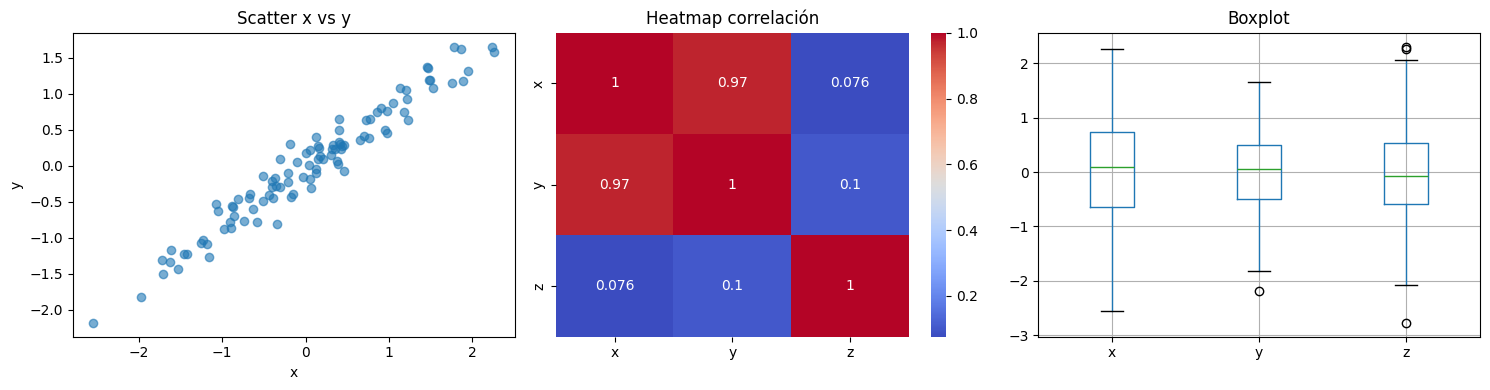

In [22]:
# ── Práctica guiada 4.3 ──────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

np.random.seed(0)
df = pd.DataFrame({
    "x": np.random.randn(100),
    "y": np.random.randn(100),
    "z": np.random.randn(100)
})
# Correlación artificial entre x e y
df["y"] = df["x"] * 0.8 + np.random.randn(100) * 0.2

# Resumen estadístico
print("--- describe ---")
print(df.describe())

# Matrices de correlación
print("\n--- Pearson ---")
print(df.corr(method="pearson").round(3))
print("\n--- Spearman ---")
print(df.corr(method="spearman").round(3))

# Correlación puntual
print(f"\nCorrelación x-y (Pearson): {df['x'].corr(df['y']):.3f}")

# Visualizaciones
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Pairplot simplificado (scatter x vs y)
axes[0].scatter(df["x"], df["y"], alpha=0.6)
axes[0].set_title("Scatter x vs y")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")

# Heatmap de correlación
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", ax=axes[1])
axes[1].set_title("Heatmap correlación")

# Boxplot
df.boxplot(ax=axes[2])
axes[2].set_title("Boxplot")

plt.tight_layout()
plt.show()

### 4.3.4 Test

1. La media es sensible a… **b) outliers**
2. La mediana es… **b) valor central**
3. Pearson mide… **b) lineal**
4. Spearman mide… **b) monotónica**
5. Un heatmap de correlación muestra… **b) relaciones**
6. Un boxplot detecta… **b) outliers**
7. `describe` incluye… **b) estadísticas**
8. La varianza mide… **b) dispersión**
9. Un patrón estacional… **b) repetición periódica**
10. EDA sirve para… **b) entender datos**

---
## Epígrafe 4.4 — Desarrollo de modelos en Python

### 4.4.1 Conceptos clave

- **Regresión lineal**: `y = a + bx + e`.
- **Regresión no lineal**: polinómica, logística, árboles.
- **Muestreo**: train/test split, validación cruzada.
- **Predicción**: `predict`, métricas (MSE, RMSE, R²).
- **Precisión y validez**: sobreajuste, subajuste.

### 4.4.2 Explicación razonada

**Regresión lineal**: modela relación entre variable dependiente y una o más independientes. Se ajusta minimizando suma de cuadrados. `scikit-learn` o `statsmodels`.

**No lineal**: cuando la relación no es lineal. Se usan transformaciones, polinomios, árboles, SVM, redes.

**Muestreo**: dividir en train/test. Validación cruzada (k-fold) para estimar rendimiento.

**Métricas**:
- MSE: error cuadrático medio.
- RMSE: raíz del MSE.
- R²: proporción de varianza explicada.

**Sobreajuste**: modelo memoriza train, mal en test. Soluciones: regularización, más datos, modelo más simple.

=== Regresión lineal ===
Coeficiente: 1.987
Intercepto:  1.322
MSE:         1.043
R²:          0.972

=== Regresión polinómica (grado 2) ===
R² (test):   0.972


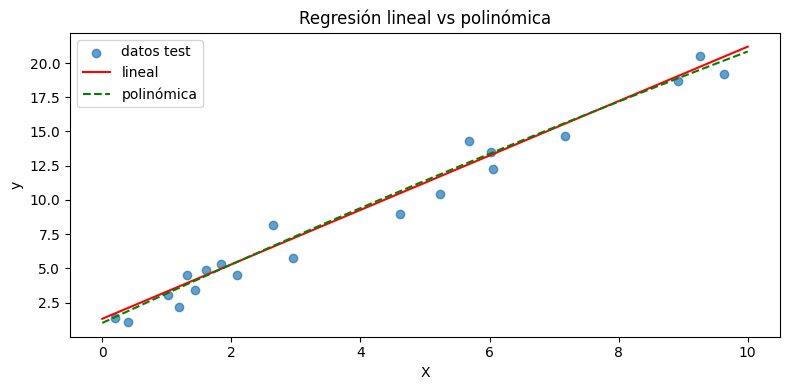

In [23]:
# ── Práctica guiada 4.4 ──────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Datos sintéticos
np.random.seed(0)
X = np.random.rand(100, 1) * 10
y = 2 * X.squeeze() + 1 + np.random.randn(100)

# División train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

# Modelo lineal
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("=== Regresión lineal ===")
print(f"Coeficiente: {model.coef_[0]:.3f}")
print(f"Intercepto:  {model.intercept_:.3f}")
print(f"MSE:         {mean_squared_error(y_test, y_pred):.3f}")
print(f"R²:          {r2_score(y_test, y_pred):.3f}")

# Modelo polinómico (no lineal)
poly = make_pipeline(PolynomialFeatures(2), LinearRegression())
poly.fit(X_train, y_train)
print(f"\n=== Regresión polinómica (grado 2) ===")
print(f"R² (test):   {poly.score(X_test, y_test):.3f}")

# Visualización
X_plot = np.linspace(0, 10, 200).reshape(-1, 1)
plt.figure(figsize=(8, 4))
plt.scatter(X_test, y_test, label="datos test", alpha=0.7)
plt.plot(X_plot, model.predict(X_plot), label="lineal", color="red")
plt.plot(X_plot, poly.predict(X_plot), label="polinómica", color="green", linestyle="--")
plt.legend()
plt.title("Regresión lineal vs polinómica")
plt.xlabel("X")
plt.ylabel("y")
plt.tight_layout()
plt.show()

### 4.4.4 Test

1. Regresión lineal ajusta… **b) recta**
2. `train_test_split` sirve para… **b) dividir**
3. MSE mide… **b) error cuadrático**
4. R² mide… **b) varianza explicada**
5. Sobreajuste es… **b) mal test**
6. Validación cruzada… **b) k splits**
7. Regresión logística… **b) clasificación**
8. Polinómica es… **b) no lineal**
9. `predict` devuelve… **b) predicciones**
10. Regularización evita… **b) sobreajuste**

---
# MÓDULO COMPLEMENTARIO — PYTHON DESDE LA CONSOLA INTERACTIVA (REPL)

Este módulo enseña a trabajar con el intérprete interactivo de Python desde **CMD o PowerShell** en Windows.
Cada sección incluye una explicación y una celda ejecutable equivalente al comportamiento del REPL.

> **Nota**: en el REPL real los prompts `>>>` y `...` los muestra Python. Aquí, en el notebook, el kernel ejecuta el código directamente sin necesidad de esos prefijos.

## Sección 1 — Entrar en Python y los prompts `>>>` y `...`

Desde **CMD** o **PowerShell** escribe:

```text
C:\Users\grach> python
Python 3.x.x ...
>>>
```

A partir de ese momento ya no estás en Windows: estás escribiendo **código Python**.

### `>>>` — prompt principal
Python espera una **nueva instrucción**.

### `...` — prompt de continuación
Python sabe que la instrucción **aún no ha terminado** y espera más código. Aparece tras `:` (bloques `if`, `for`, `def`, `class`…).  
Para cerrar el bloque pulsa **Enter en una línea vacía**.

```text
>>> if 10 > 5:
...     print("Es mayor")
...                        ← Enter vacío aquí
Es mayor
>>>
```

### Característica especial del REPL
Las expresiones **imprimen su resultado automáticamente**, sin `print()`:

```python
>>> 2 + 3
5
>>> nombre = "Jose"   # asignación → no imprime
>>> nombre            # evaluar variable → sí imprime
'Jose'
```

### Salir del REPL
```python
>>> exit()   # o quit()
```
También **Ctrl+Z + Enter** en CMD / **Ctrl+D** en Linux/macOS.

In [24]:
# ── Práctica 1a — Expresiones: el REPL muestra el resultado automáticamente ──
2 + 3

5

In [25]:
# ── Práctica 1b — Asignación vs evaluación ───────────────────────────────────
nombre = "Jose"   # asignación: no imprime nada
nombre            # evaluar: imprime el valor

'Jose'

In [26]:
# ── Práctica 1c — Bloque if (equivalente al prompt ...) ──────────────────────
if 10 > 5:
    print("Es mayor")   # Enter vacío después del bloque = se ejecuta

Es mayor


## Sección 2 — `:`, indentación y `;`

### El `:`
Abre un **bloque de código**. Lo usan: `if`, `elif`, `else`, `for`, `while`, `def`, `class`, `try`, `except`, `with`.

```text
instrucción_que_abre_bloque:
    código del bloque  ← 4 espacios
```

### Indentación
Python usa la **sangría** para delimitar bloques. Un error de indentación produce `IndentationError`.

```python
# Correcto
if 10 > 5:
    print("A")   # 4 espacios
    print("B")

# Incorrecto → IndentationError
if 10 > 5:
print("A")       # sin sangría
```

### `;` — varias instrucciones en una línea
Útil en el REPL para pruebas rápidas, **no recomendado** en código de producción:

```python
>>> x = 10; y = 20; print(x + y)
30
```

### Instrucciones de bloque en una sola línea
```python
>>> if 10 > 5: print("Mayor")
Mayor
>>> for x in [1, 2, 3]: print(x)
1
2
3
```

In [27]:
# ── Práctica 2 — Dos puntos, indentación y punto y coma ──────────────────────

# Bloque if con indentación correcta
if 10 > 5:
    print("A")
    print("B")

# Punto y coma: varias instrucciones en una línea
x = 10; y = 20; print(x + y)

# Bloque completo en una sola línea
if 10 > 5: print("Mayor")
for x in [1, 2, 3]: print(x)

# Descomenta para ver IndentationError:
# if True:
# print("error")  # ← sin sangría → IndentationError

A
B
30
Mayor
1
2
3


## Sección 3 — `type()`, `dir()`, `help()` e `isinstance()`

Estas funciones convierten el REPL en una **herramienta de exploración** del lenguaje.

### `type(objeto)` — ¿qué tipo es esto?
```python
>>> type(10)        → <class 'int'>
>>> type(10.5)      → <class 'float'>
>>> type("Hola")   → <class 'str'>
>>> type(True)      → <class 'bool'>
>>> type([1,2,3])   → <class 'list'>
```

### `dir(objeto)` — ¿qué puedo hacer con esto?
Lista todos los atributos y métodos disponibles:
```python
>>> dir("Hola")  → [..., 'upper', 'lower', 'replace', 'split', ...]
>>> dir()        → variables definidas en el entorno actual
```

### `help(objeto)` — documentación completa
```python
>>> help(str.upper)   # pulsa q para salir
>>> help(print)
```

### `isinstance(objeto, clase)` — ¿pertenece a esta clase?
```python
>>> isinstance(10, int)      → True
>>> isinstance("Hola", str)  → True
```

### Flujo de trabajo con el REPL
```text
objeto → dir(objeto) → buscar método → objeto.método() → help(método)
```

In [28]:
# ── Práctica 3 — type(), dir(), help(), isinstance() ─────────────────────────

# type() con distintos objetos
for valor in [10, 10.5, "Hola", True, [1,2,3], {"a":1}, (1,2), {1,2}]:
    print(f"type({repr(valor):<15}) → {type(valor)}")

print()

# dir() sobre un string (filtramos __dunder__ para mayor claridad)
texto = "Hola"
metodos_str = [m for m in dir(texto) if not m.startswith("_")]
print("Métodos de str:", metodos_str)

print()

# Usar métodos descubiertos con dir()
print(texto.upper())
print(texto.replace("H", "J"))
print(texto.lower())

print()

# isinstance()
print(isinstance(10, int))       # True
print(isinstance("Hola", str))   # True
print(isinstance(10, float))     # False
print(isinstance(True, int))     # True — bool es subclase de int

print()

# help() capturado como texto
import pydoc
print(pydoc.render_doc(str.upper, renderer=pydoc.plaintext))

type(10             ) → <class 'int'>
type(10.5           ) → <class 'float'>
type('Hola'         ) → <class 'str'>
type(True           ) → <class 'bool'>
type([1, 2, 3]      ) → <class 'list'>
type({'a': 1}       ) → <class 'dict'>
type((1, 2)         ) → <class 'tuple'>
type({1, 2}         ) → <class 'set'>

Métodos de str: ['capitalize', 'casefold', 'center', 'count', 'encode', 'endswith', 'expandtabs', 'find', 'format', 'format_map', 'index', 'isalnum', 'isalpha', 'isascii', 'isdecimal', 'isdigit', 'isidentifier', 'islower', 'isnumeric', 'isprintable', 'isspace', 'istitle', 'isupper', 'join', 'ljust', 'lower', 'lstrip', 'maketrans', 'partition', 'removeprefix', 'removesuffix', 'replace', 'rfind', 'rindex', 'rjust', 'rpartition', 'rsplit', 'rstrip', 'split', 'splitlines', 'startswith', 'strip', 'swapcase', 'title', 'translate', 'upper', 'zfill']

HOLA
Jola
hola

True
True
False
True

Python Library Documentation: method_descriptor

upper(self, /) unbound builtins.str method
    Retu

## Sección 4 — Variables, tipado dinámico y `_`

Una variable se crea **simplemente asignando** un valor. No hay que declarar el tipo:

```python
>>> nombre = "Jose"
>>> edad = 30
>>> altura = 1.75
```

El tipo puede **cambiar** a lo largo del programa (tipado dinámico):

```python
>>> x = 10       # int
>>> x = "Hola"  # str
>>> x = 3.14     # float
```

Pero las operaciones entre tipos incompatibles lanzan `TypeError` (tipado **fuerte**):

```python
>>> "Hola" + 5   # TypeError
```

### `_` — el último resultado en el REPL

En la consola interactiva, `_` guarda el **último valor evaluado**:

```python
>>> 10 + 20
30
>>> _ + 5
35
```

> En el notebook `_` funciona igual: contiene la última expresión evaluada de la celda anterior.

In [29]:
# ── Práctica 4a — Variables y tipado dinámico ─────────────────────────────────

nombre = "Jose"
edad   = 30
altura = 1.75
print(nombre, edad, altura)
print(type(nombre), type(edad), type(altura))

# Tipado dinámico: la variable cambia de tipo
x = 10;      print(f"x = {x!r:<10}  tipo: {type(x).__name__}")
x = "Hola";  print(f"x = {x!r:<10}  tipo: {type(x).__name__}")
x = 3.14;    print(f"x = {x!r:<10}  tipo: {type(x).__name__}")

# TypeError por operación incompatible
try:
    "Hola" + 5
except TypeError as e:
    print(f"TypeError: {e}")

# Expresión para que _ la recoja
10 + 20

Jose 30 1.75
<class 'str'> <class 'int'> <class 'float'>
x = 10          tipo: int
x = 'Hola'      tipo: str
x = 3.14        tipo: float
TypeError: can only concatenate str (not "int") to str


30

In [30]:
# ── Práctica 4b — _ contiene el último resultado ─────────────────────────────
# _ tiene 30 (resultado de la última expresión de la celda anterior)
_ + 5

35

## Sección 5 — Strings: comillas, `'''`, docstrings, `#` y f-strings

### Comillas simples y dobles — equivalentes
```python
>>> nombre = 'Jose'
>>> nombre = "Jose"
```

### Strings multilínea con `'''` o `"""`
```python
>>> texto = '''Hola
... esto es
... varias líneas'''
>>> print(texto)
```

### `'''` como docstring
Cuando aparece justo **dentro** de una función o clase, es documentación accesible con `help()`:
```python
def saludar():
    '''Esta función muestra un saludo.'''
    print("Hola")

help(saludar)
```

### Diferencia entre `#` y `'''`
- `#` → comentario real, Python lo ignora completamente.
- `'''...'''` → objeto string; como docstring documenta, pero sigue siendo un valor.

### f-strings
```python
>>> nombre = "Jose"; edad = 50
>>> print(f"Me llamo {nombre} y tengo {edad} años")
>>> print(f"El año que viene tendré {edad + 1}")   # expresión
>>> print(f"Precio: {19.9876:.2f} €")              # 2 decimales
>>> print(f"{0.8567:.1%}")                          # porcentaje
```

In [31]:
# ── Práctica 5 — Strings, ''', docstrings, comentarios y f-strings ────────────

# Comillas equivalentes
a = 'Jose'
b = "Jose"
print("¿Son iguales?", a == b)   # True

# Multilínea con '''
texto = '''Hola
esto es
una cadena
de varias líneas'''
print(texto)
print("Tipo:", type(texto))

# Docstring accesible con __doc__
def saludar():
    '''Esta función muestra un saludo. Ejemplo de docstring.'''
    print("Hola")

print("Docstring:", saludar.__doc__)
saludar()

# Comentario (Python lo ignora)
edad = 50  # Edad del usuario

# f-strings
nombre = "Jose"
print(f"Me llamo {nombre} y tengo {edad} años")
print(f"El año que viene tendré {edad + 1}")

# Formateo numérico
precio = 19.9876
print(f"Precio: {precio:.2f} €")
porcentaje = 0.8567
print(f"Porcentaje: {porcentaje:.1%}")

# Expresión dentro de f-string
a, b = 10, 20
print(f"La suma de {a} y {b} es {a + b}")

¿Son iguales? True
Hola
esto es
una cadena
de varias líneas
Tipo: <class 'str'>
Docstring: Esta función muestra un saludo. Ejemplo de docstring.
Hola
Me llamo Jose y tengo 50 años
El año que viene tendré 51
Precio: 19.99 €
Porcentaje: 85.7%
La suma de 10 y 20 es 30


## Sección 6 — `if / elif / else`, `pass` y `while`

### `if / elif / else`
```python
>>> nota = 7
>>> if nota >= 9:
...     print("Excelente")
... elif nota >= 5:
...     print("Aprobado")
... else:
...     print("Suspenso")
...
Aprobado
```
`elif` y `else` también llevan `:` y deben estar **al mismo nivel** que el `if`.

### `pass` — marcador de posición
`pass` significa *no hagas nada*. Python exige que todo bloque tenga al menos una instrucción:
```python
def calcular():
    pass        # implementaré esto más tarde

class MiClase:
    pass
```

### `while`
```python
>>> contador = 0
>>> while contador < 3:
...     print(contador)
...     contador += 1
...
0
1
2
```
Para interrumpir un bucle infinito en el REPL real: **Ctrl+C** → `KeyboardInterrupt`.  
En el notebook usa el botón **■ (Interrupt kernel)**.

In [32]:
# ── Práctica 6 — if/elif/else, pass y while ───────────────────────────────────

# if / elif / else
nota = 7
if nota >= 9:
    print("Excelente")
elif nota >= 5:
    print("Aprobado")
else:
    print("Suspenso")

# Varios valores
for n in [10, 7, 3, 9, 4]:
    if n >= 9:
        cat = "Excelente"
    elif n >= 5:
        cat = "Aprobado"
    else:
        cat = "Suspenso"
    print(f"  nota {n} → {cat}")

print()

# pass como marcador de posición
def calcular():
    pass   # TODO: implementar

class MiClase:
    pass

print("calcular():", calcular())   # None — existe pero no hace nada
print("MiClase():  ", MiClase())

print()

# while
contador = 0
while contador < 3:
    print(f"  contador = {contador}")
    contador += 1

# while con break (equivale a Ctrl+C controlado)
i = 0
while True:
    if i >= 4:
        break
    print(f"  i = {i}")
    i += 1

Aprobado
  nota 10 → Excelente
  nota 7 → Aprobado
  nota 3 → Suspenso
  nota 9 → Excelente
  nota 4 → Suspenso

calcular(): None
MiClase():   <__main__.MiClase object at 0x79e0fc4ba900>

  contador = 0
  contador = 1
  contador = 2
  i = 0
  i = 1
  i = 2
  i = 3


## Sección 7 — Funciones: `def`, parámetros, `return`

### Definir y llamar
```python
>>> def saludar():
...     print("Hola")
...
>>> saludar()
Hola
```

### Con parámetros
```python
>>> def saludar(nombre):
...     print(f"Hola {nombre}")
...
>>> saludar("Jose")
Hola Jose
```

### Con `return`
```python
>>> def sumar(a, b):
...     return a + b
...
>>> resultado = sumar(10, 20)
>>> resultado
30
```

### `dir()` sobre una función
```python
>>> dir(sumar)   # muestra __name__, __doc__, __code__, etc.
```

In [33]:
# ── Práctica 7 — def, parámetros, return ──────────────────────────────────────

# Sin parámetros
def saludar():
    print("Hola")

saludar()

# Con parámetro
def saludar_a(nombre):
    print(f"Hola {nombre}")

saludar_a("Jose")

# Con return
def sumar(a, b):
    return a + b

resultado = sumar(10, 20)
print("Resultado:", resultado)

# Con docstring y parámetro por defecto
def presentar(nombre, edad, ciudad="desconocida"):
    '''Imprime una presentación del usuario.'''
    print(f"Me llamo {nombre}, tengo {edad} años y soy de {ciudad}")

presentar("Jose", 50)
presentar("Ana", 30, "Madrid")
print("Docstring:", presentar.__doc__)

# dir() sobre una función
atributos_fun = [a for a in dir(sumar) if not a.startswith("__")]
print("Atributos de sumar():", atributos_fun)

Hola
Hola Jose
Resultado: 30
Me llamo Jose, tengo 50 años y soy de desconocida
Me llamo Ana, tengo 30 años y soy de Madrid
Docstring: Imprime una presentación del usuario.
Atributos de sumar(): []


## Sección 8 — Clases desde el REPL

Se pueden definir clases directamente en la consola:

```python
>>> class Persona:
...     def __init__(self, nombre, edad):
...         self.nombre = nombre
...         self.edad = edad
...
...     def saludar(self):
...         print(f"Hola, soy {self.nombre}")
...
>>> p = Persona("Jose", 50)
>>> p.nombre
'Jose'
>>> p.saludar()
Hola, soy Jose
>>> type(p)
<class '__main__.Persona'>
>>> isinstance(p, Persona)
True
>>> dir(p)    # incluye nombre, saludar, ...
```

Jerarquía de capas:

```text
class Persona
  └── __init__  → inicializa atributos (nombre, edad)
  └── saludar   → método de instancia

p = Persona("Jose", 50)   → instancia
  └── p.nombre            → atributo
  └── p.saludar()         → llamada a método
```

In [34]:
# ── Práctica 8 — Clases en el REPL ───────────────────────────────────────────

class Persona:
    def __init__(self, nombre, edad):
        self.nombre = nombre
        self.edad   = edad

    def saludar(self):
        print(f"Hola, soy {self.nombre}")

    def presentar(self):
        '''Devuelve una presentación completa.'''
        return f"Me llamo {self.nombre} y tengo {self.edad} años"

# Crear instancia
p = Persona("Jose", 50)

# Acceder a atributos
print("nombre:", p.nombre)
print("edad:  ", p.edad)

# Llamar a métodos
p.saludar()
print(p.presentar())

# type() e isinstance()
print("type:", type(p))
print("isinstance(p, Persona):", isinstance(p, Persona))
print("isinstance(p, object): ", isinstance(p, object))  # toda clase hereda de object

# dir() — atributos propios sin dunder
atributos = [a for a in dir(p) if not a.startswith("_")]
print("dir(p) sin dunder:", atributos)

# Varias instancias
personas = [Persona("Ana", 30), Persona("Luis", 25), Persona("Eva", 45)]
for per in personas:
    print(f"  {per.presentar()}")

nombre: Jose
edad:   50
Hola, soy Jose
Me llamo Jose y tengo 50 años
type: <class '__main__.Persona'>
isinstance(p, Persona): True
isinstance(p, object):  True
dir(p) sin dunder: ['edad', 'nombre', 'presentar', 'saludar']
  Me llamo Ana y tengo 30 años
  Me llamo Luis y tengo 25 años
  Me llamo Eva y tengo 45 años


## Sección 9 — TAB, cursores, `Ctrl+C` y chuleta completa

### TAB — autocompletado (solo en REPL real y en el notebook)
```text
>>> texto = "Hola"
>>> texto.      ← pulsa TAB
```
Muestra todos los métodos disponibles. En VS Code/Kiro también funciona con `Ctrl+Space`.

### ↑ ↓ — historial de comandos
```text
>>> nombre = "Jose"
>>> edad = 50
>>> print(nombre)
↑  →  recuperas print(nombre)
↑  →  recuperas edad = 50
```
Puedes editar la línea recuperada con **← →** antes de ejecutarla.

### `Ctrl+C` — interrumpir
```python
>>> while True:
...     print("Hola")
KeyboardInterrupt    ← Ctrl+C
>>>
```
En el notebook usa **■ (Interrupt kernel)**.

---

### Chuleta completa del REPL

| Elemento | Significado |
|---|---|
| `>>>` | Python espera nueva instrucción |
| `...` | Python espera continuación del bloque |
| `:` | Abre un bloque |
| 4 espacios | Indentación obligatoria |
| `;` | Varias instrucciones en una línea |
| `.` | Accede a atributos/métodos |
| `TAB` | Autocompletado |
| `↑ ↓` | Historial de comandos |
| `← →` | Moverse por la línea |
| `Ctrl+C` | Interrumpir → `KeyboardInterrupt` |
| `exit()` / `quit()` | Salir de Python |
| `type(x)` | Tipo del objeto |
| `dir(x)` | Atributos y métodos |
| `help(x)` | Documentación |
| `isinstance(x, C)` | Pertenencia a clase |
| `_` | Último resultado evaluado |
| `#` | Comentario |
| `'''...'''` | String multilínea / docstring |
| `f"...{expr}"` | String formateado |
| `pass` | No hacer nada (marcador) |
| `if / elif / else` | Condicional |
| `for / while` | Bucles |
| `def` | Definir función |
| `class` | Definir clase |
| `return` | Devolver resultado |

In [35]:
# ── Práctica 9 — Sesión REPL completa (sección 44 del tutorial) ──────────────

# Variables y f-strings
nombre = "Jose"
edad   = 50
print(f"Hola, me llamo {nombre}")
print(f"Tengo {edad} años")

# if/else
if edad >= 18:
    print("Soy mayor de edad")
else:
    print("Soy menor de edad")

# for con f-string
for i in range(3):
    print(f"Iteración {i}")

# Función con docstring
def presentar(nombre, edad):
    '''Imprime una presentación.'''
    print(f"Me llamo {nombre} y tengo {edad} años")

presentar(nombre, edad)

# Clase
class Persona:
    def __init__(self, nombre, edad):
        self.nombre = nombre
        self.edad   = edad
    def __repr__(self):
        return f"Persona({self.nombre!r}, {self.edad})"

p = Persona(nombre, edad)
print(p)
print("type:      ", type(p))
print("isinstance:", isinstance(p, Persona))

# _ — evaluamos una expresión para que _ la recoja
10 + 20

Hola, me llamo Jose
Tengo 50 años
Soy mayor de edad
Iteración 0
Iteración 1
Iteración 2
Me llamo Jose y tengo 50 años
Persona('Jose', 50)
type:       <class '__main__.Persona'>
isinstance: True


30

In [36]:
# _ contiene 30 de la celda anterior
print(f"El último resultado fue {_}, y sumando 5 = {_ + 5}")

El último resultado fue 30, y sumando 5 = 35


---
# Cierre

Este notebook cubre los **4 módulos** del Curso de Especialización en Python con:

- **Conceptos clave** explicados en tablas y texto.
- **Razonamiento** orientado a estudiantes de informática.
- **Prácticas ejecutables** directamente en las celdas de código.
- **Errores frecuentes** y buenas prácticas.
- **10 preguntas tipo test** por epígrafe con las respuestas correctas marcadas.
- **Módulo complementario** sobre el REPL interactivo de Python.

Para cambiar el intérprete Python utiliza el selector de kernel en la barra superior del notebook.